In [2]:
## Q.2 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

df = pd.read_csv("carbon.csv")

## Display variable names 

print ("variables:")
print (df.columns)


## Top 5 Rows 

print ("\nTop 5 rows:")
print(df.head())


## Bottom 10 rows  

print ("\nBottom 10 rows:")
print(df.tail(10))

## Data types 

print ("\nData Types:")
print(df.dtypes)


## shape

print ("\nShape:")
print(df.shape)







variables:
Index(['Year', 'total_population', 'Avg_Carbon_emmsion_per capita',
       'total_CE_Ktons', 'cerial_production_MT',
       'avg_Energy_use_kgoe_percapita', 'avg_temp_change'],
      dtype='object')

Top 5 rows:
   Year  total_population  Avg_Carbon_emmsion_per capita  total_CE_Ktons  \
0  1961       31084882437                       3.326700     74702027.06   
1  1962       31635995910                       3.498224     76920056.01   
2  1963       32321823561                       3.946614     81336518.76   
3  1964       33013039759                       4.046382     85810854.52   
4  1965       33721330129                       4.067733     90677310.78   

   cerial_production_MT  avg_Energy_use_kgoe_percapita  avg_temp_change  
0           35266122.85                    2419.869665         0.144488  
1           37632588.89                    2520.566675        -0.028981  
2           39874609.66                    2655.287306        -0.026252  
3           40913428.26 

In [3]:
## Data Cleaning

## Check and remove Duplicates

print ("Duplicate Rows:", df.duplicated().sum())

df= df.drop_duplicates()

Duplicate Rows: 0


In [4]:
## Check the missing Values 

print (df.isnull().sum())

Year                             0
total_population                 0
Avg_Carbon_emmsion_per capita    0
total_CE_Ktons                   0
cerial_production_MT             0
avg_Energy_use_kgoe_percapita    0
avg_temp_change                  0
dtype: int64


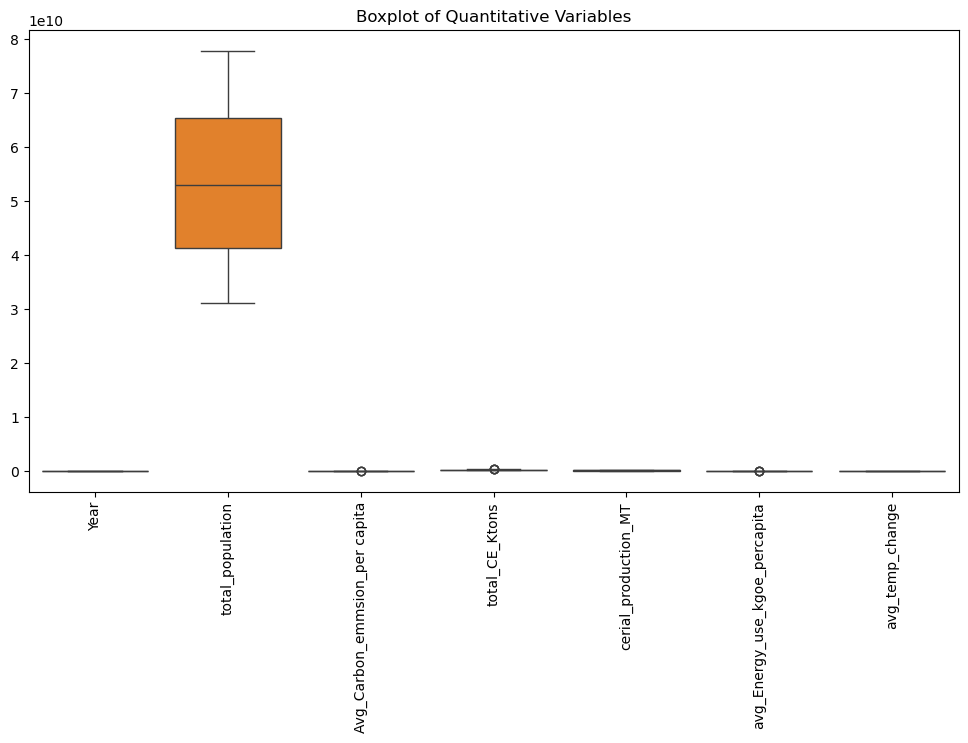

In [10]:
## Detect Outliers Using Boxplots



import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12,6))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=90)
plt.title("Boxplot of Quantitative Variables")
plt.show()

In [11]:
## Q.3  Create Real_Total_Population




df["Real_Total_population"]=df["total_population"] /10

df.head()

,Year,total_population,Avg_Carbon_emmsion_per capita,total_CE_Ktons,cerial_production_MT,avg_Energy_use_kgoe_percapita,avg_temp_change,Real_Total_population
0,1961,31084882437,3.326700,74702027.06,35266122.85,2419.869665,0.144488,3.108488e+09
1,1962,31635995910,3.498224,76920056.01,37632588.89,2520.566675,-0.028981,3.163600e+09
2,1963,32321823561,3.946614,81336518.76,39874609.66,2655.287306,-0.026252,3.232182e+09
3,1964,33013039759,4.046382,85810854.52,40913428.26,2763.369152,-0.122131,3.301304e+09
4,1965,33721330129,4.067733,90677310.78,41707289.58,2807.812550,-0.224178,3.372133e+09


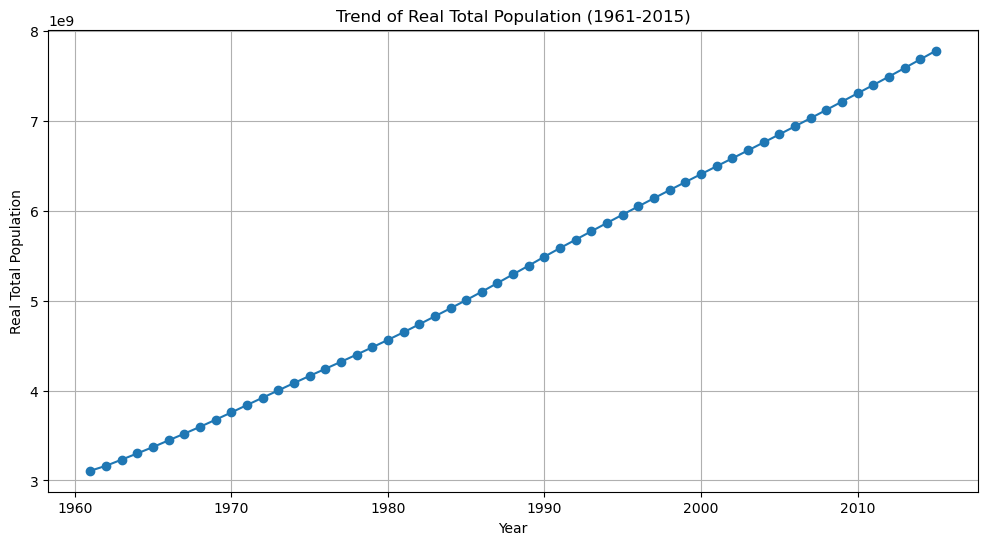

In [12]:
## Q.4 Trend Of Real_Total_Population (1961 -2015)



plt.figure(figsize=(12,6))

plt.plot(df["Year"], df["Real_Total_population"],marker='o')

plt.title("Trend of Real Total Population (1961-2015)")
plt.xlabel("Year")
plt.ylabel("Real Total Population")
plt.grid(True)

plt.show()

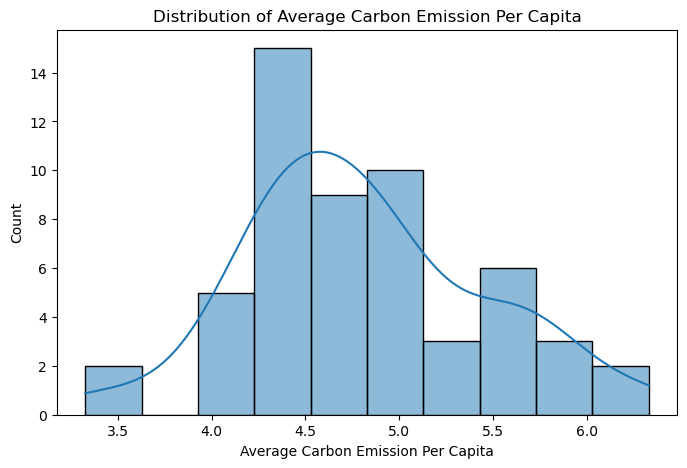

In [17]:
## Q.5 DiStribution OF AVG_CARBON_EMMISION_PER CAPITA



plt.figure(figsize=(8,5))

sns.histplot(df["Avg_Carbon_emmsion_per capita"],
             bins=10,
             kde=True)

plt.title("Distribution of Average Carbon Emission Per Capita")
plt.xlabel("Average Carbon Emission Per Capita")

plt.show()


                               Real_Total_population  \
Real_Total_population                       1.000000   
Avg_Carbon_emmsion_per capita              -0.029525   
total_CE_Ktons                              0.966086   
cerial_production_MT                        0.989936   
avg_Energy_use_kgoe_percapita               0.016576   
avg_temp_change                             0.933308   

                               Avg_Carbon_emmsion_per capita  total_CE_Ktons  \
Real_Total_population                              -0.029525        0.966086   
Avg_Carbon_emmsion_per capita                       1.000000        0.103117   
total_CE_Ktons                                      0.103117        1.000000   
cerial_production_MT                               -0.005756        0.978746   
avg_Energy_use_kgoe_percapita                      -0.283433        0.005163   
avg_temp_change                                    -0.135643        0.884485   

                               cerial_producti

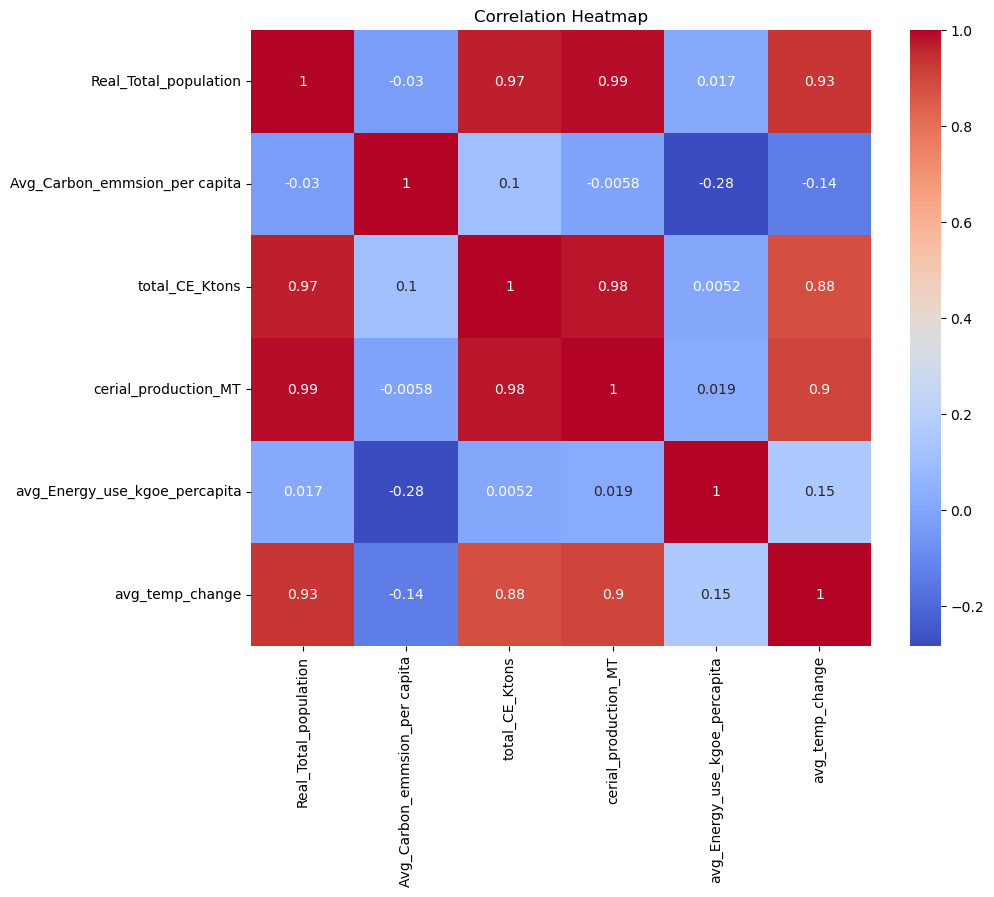

In [26]:
## Q.6 COLLELATION ANALYSIS



corr_data = df[
    [
        "Real_Total_population",
        "Avg_Carbon_emmsion_per capita",
        "total_CE_Ktons","cerial_production_MT",
        "avg_Energy_use_kgoe_percapita",
        "avg_temp_change"
    ]
  ]


corr_matrix = corr_data.corr()

print(corr_matrix)

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()



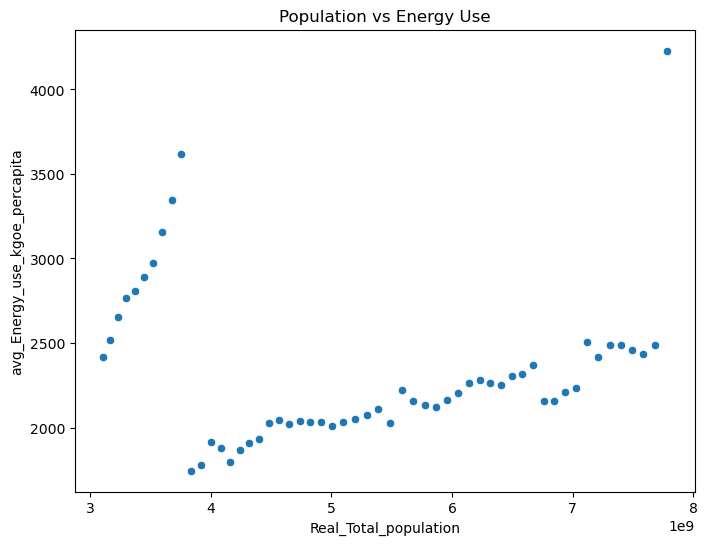

In [30]:
## Q.7 RELATIONSHIP BETWEEN POPULATION AND ENERGY USE 



plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Real_Total_population",
    y="avg_Energy_use_kgoe_percapita",
    data=df
)

plt.title("Population vs Energy Use")

plt.show()



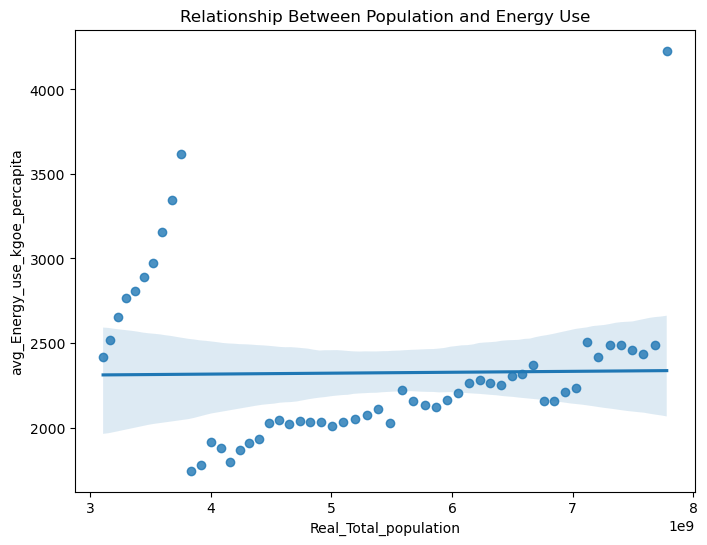

In [31]:
## Regression Line 



plt.figure(figsize=(8,6))

sns.regplot(
    x="Real_Total_population",
    y="avg_Energy_use_kgoe_percapita",
    data=df
)

plt.title("Relationship Between Population and Energy Use")

plt.show()

In [32]:
## Q.8 REGRESSION EQUATION 



from sklearn.linear_model import LinearRegression

X = df[["Real_Total_population"]]
y = df["avg_Energy_use_kgoe_percapita"]

model = LinearRegression()

model.fit(X,y)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope =", slope)
print("Intercept =", intercept)

Slope = 5.4235742686958165e-09
Intercept = 2294.8915094535146


In [33]:
## Q.9(A) PREDICT ENERGY USE FOR RWANDA IF POPULATION = 12M



prediction= model.predict([[12000000]])
print(prediction)

[2294.95659234]


C:\Users\Aimable\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [34]:
## Q.9(B) PREDICT POPULATION IF ENERGY USE = 400




x = (400 - intercept)/slope

print(x)



-349380577378.7571
